# 🤖 Modelagem de Machine Learning

## 🧠 Introdução

Após a realização da Análise Exploratória de Dados (EDA), foi possível compreender o comportamento do dataset, identificar padrões relevantes e destacar variáveis com potencial preditivo para a detecção de doenças cardíacas.

Com base nesses insights, inicia-se a etapa de modelagem de Machine Learning, cujo objetivo é construir modelos capazes de aprender padrões a partir dos dados e realizar previsões sobre a presença ou ausência da doença.

Essa etapa é fundamental para validar, na prática, as hipóteses levantadas durante a análise exploratória, permitindo avaliar quais variáveis realmente contribuem para o desempenho preditivo do modelo.

---

## 🎯 Objetivo da Modelagem

A modelagem tem como principais objetivos:

- Construir modelos de classificação para prever a variável alvo (`Doenca_cardiaca`)  
- Avaliar o desempenho dos modelos utilizando métricas adequadas (accuracy, precision, recall e F1-score)  
- Comparar diferentes algoritmos, analisando seus pontos fortes e limitações  
- Ajustar hiperparâmetros para otimizar os resultados  
- Melhorar a capacidade de generalização dos modelos  


# 1. Conhecendo a Base de Dados

In [38]:
import pandas as pd

dados = pd.read_csv('/content/doenca_cardiaca.csv')
dados.head()

,Idade,Sexo,Tipo dor,Pressao arterial,Colesterol,Glicemia jejum >120,Resultados ECG,Frequencia cardiaca max,Dor exercicio,Depressao ST,Inclinacao ST,Numero vasos fluro,Teste cintilografia,Doenca cardiaca
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presenca
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Ausencia
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presenca
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Ausencia
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Ausencia


## 🔍 Análises Preliminares


### 🧾 Estrutura e Tipos de Dados

A verificação inicial (`.info()`) mostrou que o dataset possui **270 registros e 14 variáveis**, com predominância de dados numéricos. A variável alvo (`Doenca_cardiaca`) está representada como categórica.


In [39]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Idade                    270 non-null    int64  
 1   Sexo                     270 non-null    int64  
 2   Tipo dor                 270 non-null    int64  
 3   Pressao arterial         270 non-null    int64  
 4   Colesterol               270 non-null    int64  
 5   Glicemia jejum >120      270 non-null    int64  
 6   Resultados ECG           270 non-null    int64  
 7   Frequencia cardiaca max  270 non-null    int64  
 8   Dor exercicio            270 non-null    int64  
 9   Depressao ST             270 non-null    float64
 10  Inclinacao ST            270 non-null    int64  
 11  Numero vasos fluro       270 non-null    int64  
 12  Teste cintilografia      270 non-null    int64  
 13  Doenca cardiaca          270 non-null    object 
dtypes: float64(1), int64(12), 

### 🎯 Variável Alvo

A variável alvo apresenta duas classes:

- **Ausência:** 56%  
- **Presença:** 44%  

A distribuição é relativamente equilibrada, o que é adequado para problemas de classificação.


In [40]:
dados['Doenca cardiaca'].unique()

array(['Presenca', 'Ausencia'], dtype=object)

In [41]:
dados['Doenca cardiaca'].value_counts(normalize=True).round(2)*100

,proportion
Doenca cardiaca,
Ausencia,56.0
Presenca,44.0


### 📏 Dimensionalidade

O dataset possui:

- **270 linhas (amostras)**  
- **14 colunas (variáveis)**  


In [42]:
print(f'Tamanho do Dataset (linhas, colunas): {dados.shape}')

Tamanho do Dataset (linhas, colunas): (270, 14)


### 🔍 Valores Ausentes

Não foram identificados valores nulos em nenhuma das variáveis, eliminando a necessidade de tratamento para dados faltantes.


In [43]:
print(dados.isnull().sum())

Idade                      0
Sexo                       0
Tipo dor                   0
Pressao arterial           0
Colesterol                 0
Glicemia jejum >120        0
Resultados ECG             0
Frequencia cardiaca max    0
Dor exercicio              0
Depressao ST               0
Inclinacao ST              0
Numero vasos fluro         0
Teste cintilografia        0
Doenca cardiaca            0
dtype: int64


### 🔁 Dados Duplicados

Não foram encontrados registros duplicados, garantindo maior confiabilidade na base.


In [44]:
print(f'Total de Dados Duplicados : {dados.duplicated().sum()}')

Total de Dados Duplicados : 0


### 📊 Estatísticas Descritivas

As estatísticas indicam:

- Variáveis com boa variabilidade (ex: colesterol e frequência cardíaca)  
- Presença de valores extremos em algumas variáveis clínicas  
- Distribuições coerentes com dados do contexto médico  


In [45]:
dados.describe().round(2)

,Idade,Sexo,Tipo dor,Pressao arterial,Colesterol,Glicemia jejum >120,Resultados ECG,Frequencia cardiaca max,Dor exercicio,Depressao ST,Inclinacao ST,Numero vasos fluro,Teste cintilografia
count,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00,270.00
mean,54.43,0.68,3.17,131.34,249.66,0.15,1.02,149.68,0.33,1.05,1.59,0.67,4.70
std,9.11,0.47,0.95,17.86,51.69,0.36,1.00,23.17,0.47,1.15,0.61,0.94,1.94
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00
25%,48.00,0.00,3.00,120.00,213.00,0.00,0.00,133.00,0.00,0.00,1.00,0.00,3.00
50%,55.00,1.00,3.00,130.00,245.00,0.00,2.00,153.50,0.00,0.80,2.00,0.00,3.00
75%,61.00,1.00,4.00,140.00,280.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00


# 2.  📊 Análise da Variável Alvo

A distribuição da variável alvo (`Doenca_cardiaca`) indica:

- Leve predominância de pacientes sem doença  
- Boa representatividade das duas classes  

Esse equilíbrio é adequado para modelos de classificação, reduzindo riscos de viés durante o treinamento.


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('Accent')
sns.set_theme(style='darkgrid')

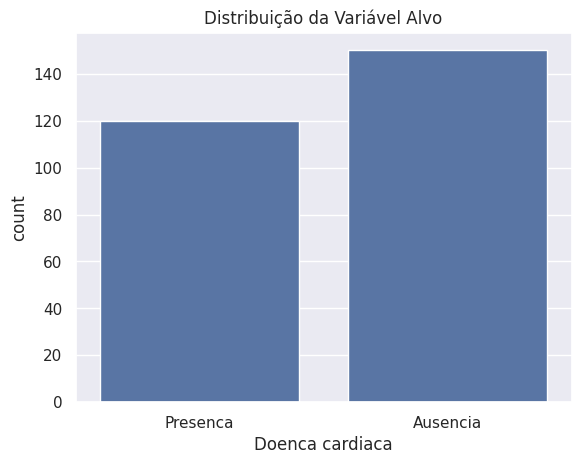

In [47]:
sns.countplot(data=dados, x='Doenca cardiaca')
plt.title('Distribuição da Variável Alvo')
plt.show()

# 3. Divisão dos Dados + Pré-Processamento

### 🔤 Codificação da Variável Alvo

A variável alvo (`Doenca_cardiaca`) foi transformada para formato numérico utilizando `LabelEncoder`, convertendo as categorias em valores binários (0 e 1), o que permite sua utilização em modelos de classificação.

In [48]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
dados['Doenca cardiaca'] = le.fit_transform(dados['Doenca cardiaca'])

In [49]:
dados['Doenca cardiaca'].unique()

array([1, 0])

### 🧩 Separação entre Variáveis (X e y)

O dataset foi dividido em:

- **X:** variáveis explicativas (features)  
- **y:** variável alvo (`Doenca_cardiaca`)  

Essa separação é essencial para o treinamento supervisionado dos modelos.

In [50]:
X = dados.drop('Doenca cardiaca', axis=1)

y = dados['Doenca cardiaca']

### 🔀 Divisão em Treino e Teste

Os dados foram divididos em conjuntos de treino e teste, utilizando uma proporção de **80% para treino** e **20% para teste**.

Foi aplicada a técnica de **estratificação**, garantindo que a distribuição das classes fosse mantida em ambos os conjuntos, proporcionando uma avaliação mais consistente do modelo.

In [51]:
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, stratify=y, test_size=0.2, random_state=123)

## ⚙️ Pré-Processamento dos Dados

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### 📏 Padronização das Variáveis

Foi aplicado um processo de **padronização dos dados** utilizando o `StandardScaler`, com o objetivo de colocar todas as variáveis na mesma escala.

Essa técnica transforma os dados para que tenham:

- Média igual a 0  
- Desvio padrão igual a 1  


In [53]:
pre_processamento = Pipeline([
    ('scaler', StandardScaler())
])

### 🔄 Aplicação via Pipeline

A padronização foi implementada por meio de um `Pipeline`, garantindo um fluxo organizado e evitando vazamento de dados (data leakage).

O ajuste (`fit_transform`) foi realizado apenas nos dados de treino, enquanto os dados de teste foram transformados utilizando os mesmos parâmetros aprendidos.


In [54]:
x_treino_tratado = pre_processamento.fit_transform(x_treino)
x_teste_tratado = pre_processamento.transform(x_teste)

In [55]:
X_treino = pd.DataFrame(x_treino_tratado, columns=list(x_treino.columns))
X_teste = pd.DataFrame(x_teste_tratado, columns=list(x_teste.columns))

In [56]:
X_treino.head()

,Idade,Sexo,Tipo dor,Pressao arterial,Colesterol,Glicemia jejum >120,Resultados ECG,Frequencia cardiaca max,Dor exercicio,Depressao ST,Inclinacao ST,Numero vasos fluro,Teste cintilografia
0,-1.163887,-1.491268,-0.209821,-0.710529,-0.128465,-0.424650,-1.042594,-0.051775,-0.714485,-0.655584,0.675659,0.391431,-0.880312
1,-0.037545,-1.491268,-1.263806,0.096320,0.745205,2.354879,0.968123,0.388519,1.399609,-0.912117,-0.964143,0.391431,-0.880312
2,-0.037545,-1.491268,-0.209821,0.269217,1.049091,2.354879,-1.042594,0.872842,-0.714485,-0.912117,-0.964143,-0.692532,-0.880312
3,1.651969,-1.491268,-2.317790,0.557377,-0.185444,-0.424650,-1.042594,0.036283,-0.714485,0.627080,-0.964143,1.475395,-0.880312
4,-2.853402,0.670570,-1.263806,-0.018944,-0.850194,-0.424650,0.968123,2.281783,-0.714485,-0.912117,-0.964143,-0.692532,-0.880312


# 4. Modelos de Machine Learning

## 🤖 Modelo Regressão Logística

A Regressão Logística foi utilizada como modelo base para classificação, com ajuste de peso das classes (`class_weight="balanced"`) para lidar com possíveis desbalanceamentos.


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay

In [58]:
modelo_lr = LogisticRegression(class_weight='balanced')
modelo_lr.fit(X_treino, y_treino)

LogisticRegression(class_weight='balanced')


### 📊 Desempenho do Modelo

O modelo apresentou:

- **Acurácia:** 0.85  
- **F1-score:** 0.85  
- **Recall (classe 1):** 0.79  

Os resultados indicam bom equilíbrio entre precisão e recall, com desempenho consistente entre as classes.


In [59]:
y_pred_lr = modelo_lr.predict(X_teste)
resultados_lr = classification_report(y_teste, y_pred_lr)
print(resultados_lr)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87        30
           1       0.86      0.79      0.83        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.85      0.85      0.85        54




### 🔍 Matriz de Confusão

A matriz de confusão mostra:

- Boa capacidade de identificar corretamente ambas as classes  
- Alguns falsos negativos (classe 1), indicando espaço para melhoria no recall  


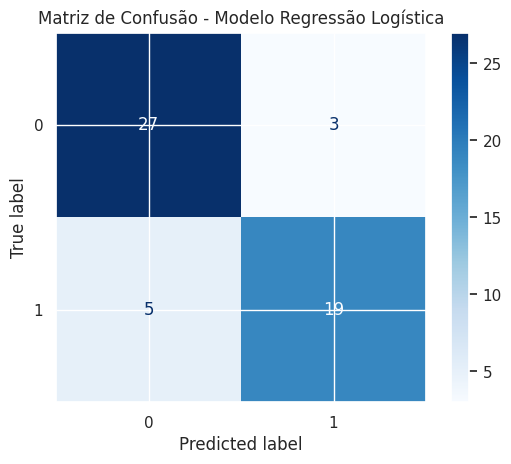

In [60]:
ConfusionMatrixDisplay.from_estimator(modelo_lr, X_teste, y_teste, cmap='Blues')
plt.title('Matriz de Confusão - Modelo Regressão Logística')
plt.show()


### 📈 Curva ROC

A curva ROC apresentou **AUC = 0.94**, indicando excelente capacidade de separação entre as classes.


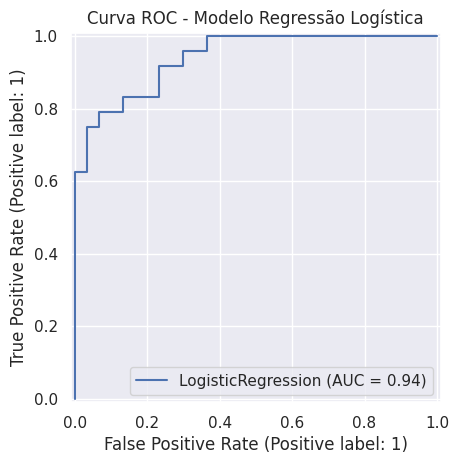

In [61]:
RocCurveDisplay.from_estimator(modelo_lr, X_teste, y_teste)
plt.title('Curva ROC - Modelo Regressão Logística')
plt.show()

## 🌳 Modelo Random Forest

O modelo Random Forest foi aplicado com controle de profundidade (`max_depth=5`) e balanceamento de classes, visando reduzir overfitting e melhorar a generalização.


In [62]:
from sklearn.ensemble import RandomForestClassifier

In [63]:
modelo_rf = RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=123)
modelo_rf.fit(X_treino, y_treino)

RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=123)

### 📊 Desempenho do Modelo

O modelo apresentou:

- **Acurácia:** 0.85  
- **F1-score:** 0.85  
- **Recall (classe 1):** 0.79  

O desempenho foi equivalente ao da Regressão Logística, indicando boa estabilidade entre diferentes abordagens.


In [64]:
y_pred_rf = modelo_rf.predict(X_teste)
resultados_rf = classification_report(y_teste, y_pred_rf)
print(resultados_rf)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87        30
           1       0.86      0.79      0.83        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.85      0.85      0.85        54



### 🔍 Matriz de Confusão

A matriz de confusão evidencia:

- Boa taxa de acerto para ambas as classes  
- Presença de falsos negativos, similar ao modelo anterior  


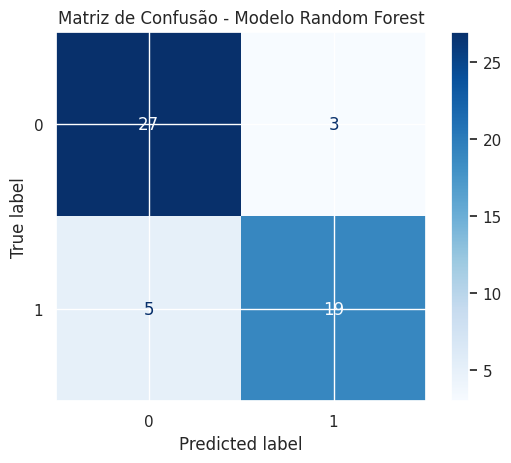

In [65]:
ConfusionMatrixDisplay.from_estimator(modelo_rf, X_teste, y_teste, cmap='Blues')
plt.title('Matriz de Confusão - Modelo Random Forest')
plt.show()

### 📈 Curva ROC

A curva ROC apresentou **AUC = 0.93**, demonstrando excelente capacidade de separação entre as classes.


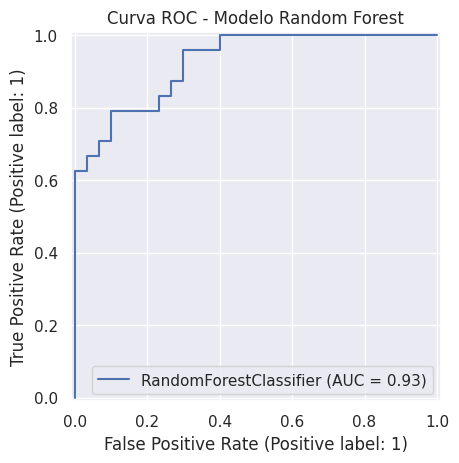

In [66]:
RocCurveDisplay.from_estimator(modelo_rf, X_teste, y_teste)
plt.title('Curva ROC - Modelo Random Forest')
plt.show()

##⚡ Modelo XGBoost

O modelo XGBoost foi aplicado como uma abordagem mais avançada baseada em boosting, capaz de capturar relações mais complexas entre as variáveis.


In [67]:
import xgboost as xgb

In [68]:
modelo_xgb = xgb.XGBClassifier()
modelo_xgb.fit(X_treino, y_treino)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

### 📊 Desempenho do Modelo

O modelo apresentou:

- **Acurácia:** 0.80  
- **F1-score:** 0.80  
- **Recall (classe 1):** 0.75  

O desempenho foi inferior aos modelos anteriores, indicando menor capacidade de generalização neste problema específico.


In [69]:
y_pred_xgb = modelo_xgb.predict(X_teste)
resultados_xgb = classification_report(y_teste, y_pred_xgb)
print(resultados_xgb)

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        30
           1       0.78      0.75      0.77        24

    accuracy                           0.80        54
   macro avg       0.79      0.79      0.79        54
weighted avg       0.80      0.80      0.80        54



### 🔍 Matriz de Confusão

A matriz de confusão mostra:

- Maior número de erros em comparação aos outros modelos  
- Aumento de falsos negativos e falsos positivos  


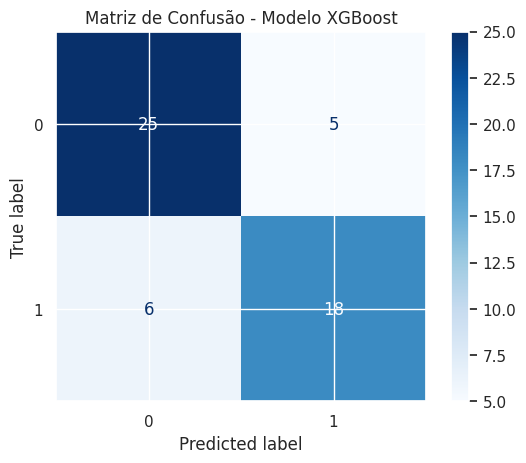

In [70]:
ConfusionMatrixDisplay.from_estimator(modelo_xgb, X_teste, y_teste, cmap='Blues')
plt.title('Matriz de Confusão - Modelo XGBoost')
plt.show()

### 📈 Curva ROC

A curva ROC apresentou **AUC = 0.91**, ainda indicando boa separação entre classes, porém inferior aos demais modelos.


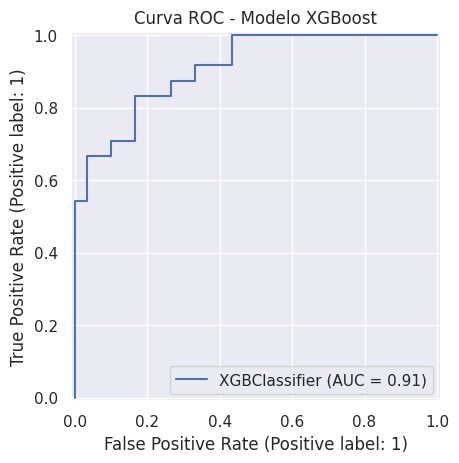

In [71]:
RocCurveDisplay.from_estimator(modelo_xgb, X_teste, y_teste)
plt.title('Curva ROC - Modelo XGBoost')
plt.show()

## 🔍 Otimização com Grid Search + Ajuste de Threshold

Para melhorar o desempenho do modelo, foi aplicado o **GridSearchCV** na Regressão Logística, com foco na otimização do **recall**, priorizando a detecção da classe positiva (presença de doença).

Os melhores parâmetros encontrados foram:

- **C:** 0.01  
- **Penalty:** L2  
- **Solver:** liblinear  

---

In [72]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

grid_lr = GridSearchCV(
    LogisticRegression(class_weight="balanced"),
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_treino, y_treino)

print("Melhores parâmetros:", grid_lr.best_params_)
print("Melhor score:", grid_lr.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Melhores parâmetros: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Melhor score: 0.8115789473684212


In [73]:
best_grid = grid_lr.best_estimator_


### ⚙️ Ajuste do Limiar de Decisão

Além da otimização dos hiperparâmetros, foi realizado ajuste manual do **threshold (limiar de decisão)**, reduzido para **0.40**.

Essa abordagem permite aumentar a sensibilidade do modelo, tornando-o mais eficiente na identificação de casos positivos.


In [74]:
y_prob = best_grid.predict_proba(X_teste)[:, 1]

In [75]:
limiar = 0.40
y_pred_ajustado = (y_prob >= limiar).astype(int)

### 📊 Desempenho do Modelo Ajustado

O modelo apresentou:

- **Recall (classe 1): 0.92** 🚀  
- **Precision (classe 1): 0.71**  
- **F1-score (classe 1): 0.80**  

Houve um aumento significativo no recall, indicando melhor capacidade de identificar pacientes com doença cardíaca.


In [76]:
resultados_grid = classification_report(y_teste, y_pred_ajustado)
print(resultados_grid)

              precision    recall  f1-score   support

           0       0.91      0.70      0.79        30
           1       0.71      0.92      0.80        24

    accuracy                           0.80        54
   macro avg       0.81      0.81      0.80        54
weighted avg       0.82      0.80      0.80        54



### 🔍 Matriz de Confusão

A matriz de confusão evidencia:

- Redução significativa de falsos negativos  
- Aumento de falsos positivos (trade-off esperado)  


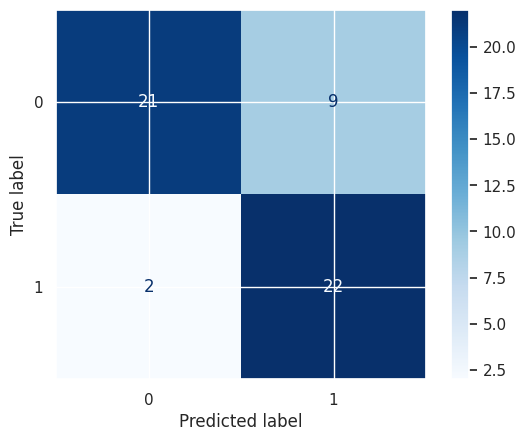

In [77]:
ConfusionMatrixDisplay.from_predictions(y_teste, y_pred_ajustado, cmap='Blues')
plt.show()


### 📈 Curva ROC

A curva ROC apresentou **AUC = 0.81**, refletindo o novo equilíbrio entre sensibilidade e precisão após o ajuste do limiar.


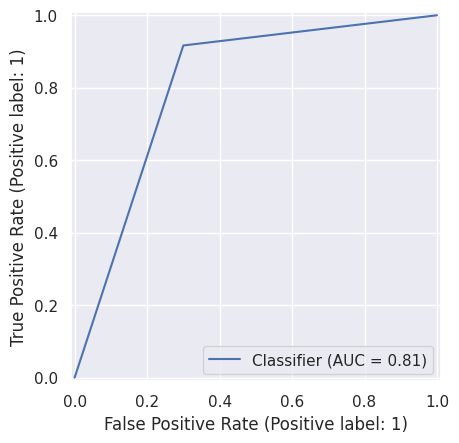

In [81]:
RocCurveDisplay.from_predictions(y_teste, y_pred_ajustado)
plt.show()

### 🧠 Conclusão

A combinação de **tuning de hiperparâmetros** e **ajuste de threshold** demonstrou ser altamente eficaz para o objetivo do problema, permitindo priorizar a detecção de casos positivos.

Essa abordagem é especialmente relevante em cenários onde **minimizar falsos negativos é mais importante**, como na identificação de doenças.


## 💾 Salvamento do Modelo e Pipeline

Após a etapa de modelagem e otimização, o modelo final e o pipeline de pré-processamento foram salvos utilizando a biblioteca `joblib`.


In [78]:
import joblib

In [79]:
joblib.dump(pre_processamento, 'preprocessamento.pkl')

['preprocessamento.pkl']

In [80]:
joblib.dump(best_grid, 'modelo_classificacao.pkl')

['modelo_classificacao.pkl']